# Prompt Visualization

Notebook started by Katy to make visuals for the AI for Oncology presentation 

In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/bhklab-nninteractive


In [2]:
from damply import dirs
from pathlib import Path
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from readii.image_processing import displayCTSegOverlay, displayImageSlice
from workflow.scripts.utils.prompts import get_prompt_points
from workflow.scripts.utils.masks import find_max_area_slice
from workflow.scripts.utils.scans import choose_windowing

In [28]:
dataset = "CVPR_LesionLocator"

# Lung example = 2013 = MSD_lung_026
sample_id = "2013"
window_l, window_w = choose_windowing('lung')

# Abdomen example = 0001 = KiTS23_case_00000
sample_id = "0001"
window_l, window_w = choose_windowing('abdomen')

# # Other
# sample_id = "2019"
# window_l, window_w = choose_windowing('lung')

In [ ]:
# baseline images
scan_path = dirs.PROCDATA / dataset / "images" / "Baseline" / f"LesionLocator_{sample_id}" / "CT.nii.gz"
mask_path = dirs.PROCDATA / dataset / "images" / "Baseline" / f"LesionLocator_{sample_id}" / "mask_1.nii.gz"

# synthetic follow-up images
# scan_path = dirs.PROCDATA / dataset / "images" / "Synthetic_Follow_Up" / f"LesionLocator_{sample_id}" / "CT.nii.gz"
# mask_path = dirs.PROCDATA/ dataset / "images" / "Synthetic_Follow_Up" / f"LesionLocator_{sample_id}" / "mask_1.nii.gz"

scan = sitk.DICOMOrient(sitk.ReadImage(scan_path), 'LPS')
mask = sitk.DICOMOrient(sitk.ReadImage(mask_path), 'LPS')

In [30]:
max_area_slice_idx = find_max_area_slice(sitk.GetArrayFromImage(mask))
max_area_slice_arr = sitk.GetArrayFromImage(mask)[max_area_slice_idx,:,:]

In [31]:
neg_pts, center_pt, recist_pts, recist_iqr_pts, _major_axis_length = get_prompt_points(max_area_slice_arr, sitk.GetArrayFromImage(scan).shape)

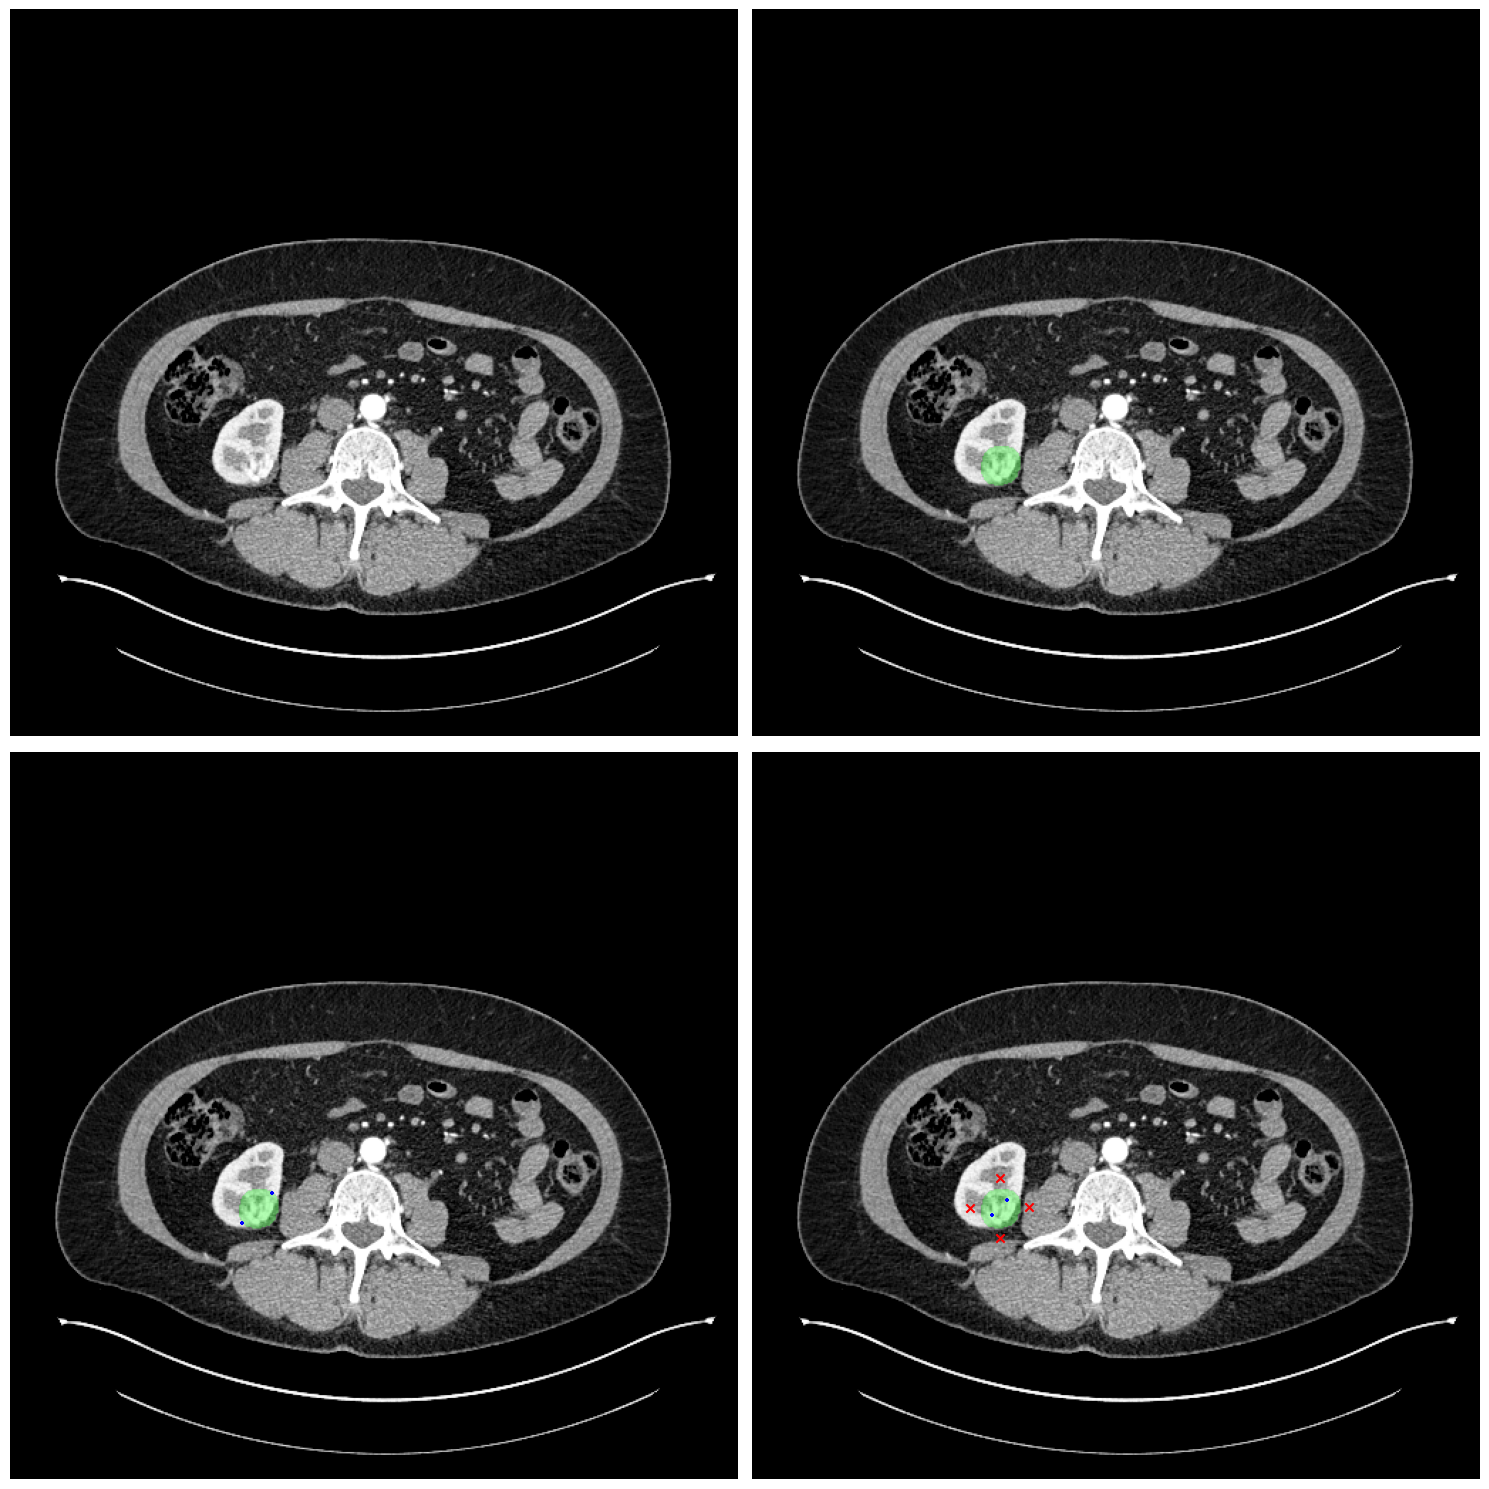

In [32]:
fig_slice, ax_slice = plt.subplots(2, 2, figsize=(15, 15), layout="tight")

dispMin = window_l - (window_w / 2)
dispMax = window_l + (window_w / 2)

ax_index= ax_slice.flatten()

displayCTSegOverlay(scan, mask, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=0, ax=ax_index[0])
displayCTSegOverlay(scan, mask, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=0.3, ax=ax_index[1])

# RECIST pts
displayCTSegOverlay(scan, mask, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=0.3, ax=ax_index[2])
ax_index[2].scatter(recist_pts[0], recist_pts[1], c='b', marker='+', s=6)
ax_index[2].scatter(recist_pts[2], recist_pts[3], c='b', marker='+', s=6)

# actual pts
displayCTSegOverlay(scan, mask, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=0.3, ax=ax_index[3])
ax_index[3].scatter(recist_iqr_pts[0], recist_iqr_pts[1], c='b', marker='+', s=6)
ax_index[3].scatter(recist_iqr_pts[2], recist_iqr_pts[3], c='b', marker='+', s=6)
ax_index[3].scatter(neg_pts[0], neg_pts[1], c='r', marker='x')
ax_index[3].scatter(neg_pts[2], neg_pts[3], c='r', marker='x')
ax_index[3].scatter(neg_pts[4], neg_pts[5], c='r', marker='x')
ax_index[3].scatter(neg_pts[6], neg_pts[7], c='r', marker='x')

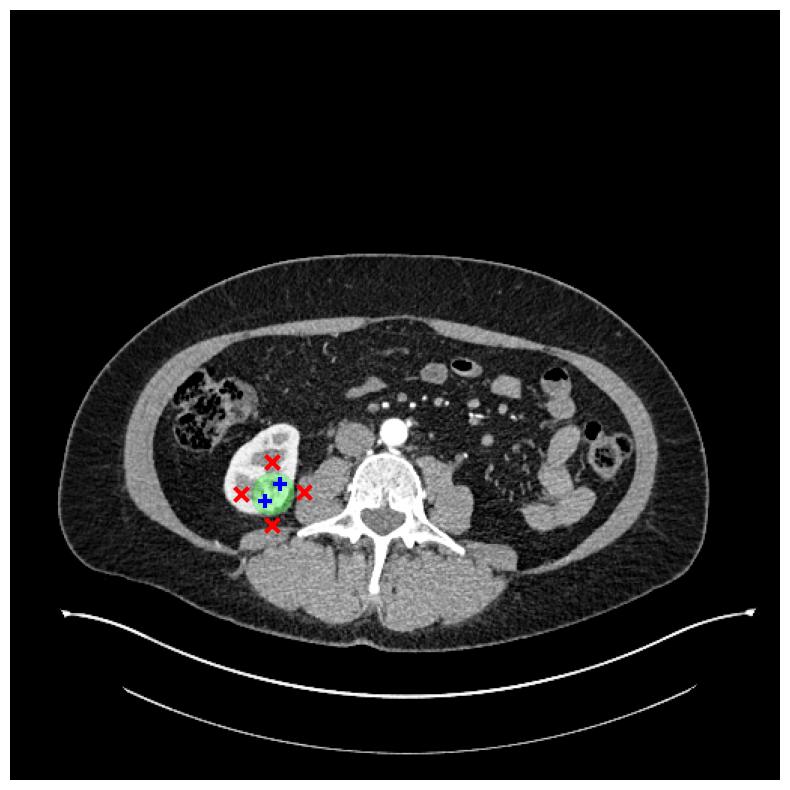

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(10,10))

displayCTSegOverlay(scan, mask, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=0.3, ax=ax)
ax.scatter(recist_iqr_pts[0], recist_iqr_pts[1], c='b', s=100, marker='+', linewidths=3)
ax.scatter(recist_iqr_pts[2], recist_iqr_pts[3], c='b', s=100, marker='+', linewidths=3)
ax.scatter(neg_pts[2], neg_pts[3], c='r', s=100, marker='x', linewidths=3)
ax.scatter(neg_pts[0], neg_pts[1], c='r', s=100, marker='x', linewidths=3)
ax.scatter(neg_pts[4], neg_pts[5], c='r', s=100, marker='x', linewidths=3)
ax.scatter(neg_pts[6], neg_pts[7], c='r', s=100, marker='x', linewidths=3)

## Trying to make border of segmentation mask

In [34]:
from skimage import morphology
from scipy.ndimage import binary_dilation

mask_arr = sitk.GetArrayFromImage(mask)

# mask_eroded = morphology.erosion(mask_arr)

# outline_arr = mask_arr ^ mask_eroded 

# outline = sitk.GetImageFromArray(outline_arr)

In [16]:
mask_arr.shape[0]

227

In [20]:
import cv2

outline_arr = np.array([cv2.Canny(mask_arr[idx], 0, 1) for idx in range(0,mask_arr.shape[0])])


outline_arr[max_area_slice_idx,187:190] = 0
outline = sitk.GetImageFromArray(outline_arr)

In [18]:
np.nonzero(outline_arr[max_area_slice_idx].sum(axis=1, keepdims=True))

(array([194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206,
        207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,
        220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232,
        233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245,
        246, 247, 248, 249, 250, 251, 252]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

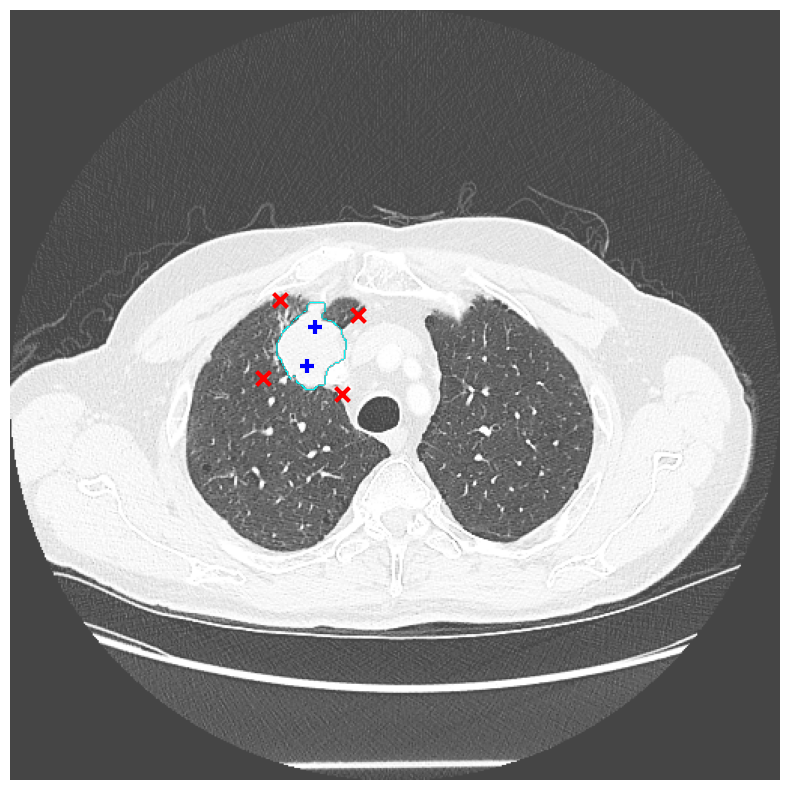

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(10,10))

displayCTSegOverlay(scan, outline, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=1, cmapSeg='cool_r', ax=ax)
ax.scatter(recist_iqr_pts[0], recist_iqr_pts[1], c='b', s=100, marker='+', linewidths=3)
ax.scatter(recist_iqr_pts[2], recist_iqr_pts[3], c='b', s=100, marker='+', linewidths=3)
ax.scatter(neg_pts[2], neg_pts[3], c='r', s=100, marker='x', linewidths=3)
ax.scatter(neg_pts[0], neg_pts[1], c='r', s=100, marker='x', linewidths=3)
ax.scatter(neg_pts[4], neg_pts[5], c='r', s=100, marker='x', linewidths=3)
ax.scatter(neg_pts[6], neg_pts[7], c='r', s=100, marker='x', linewidths=3)

## RECIST line mask

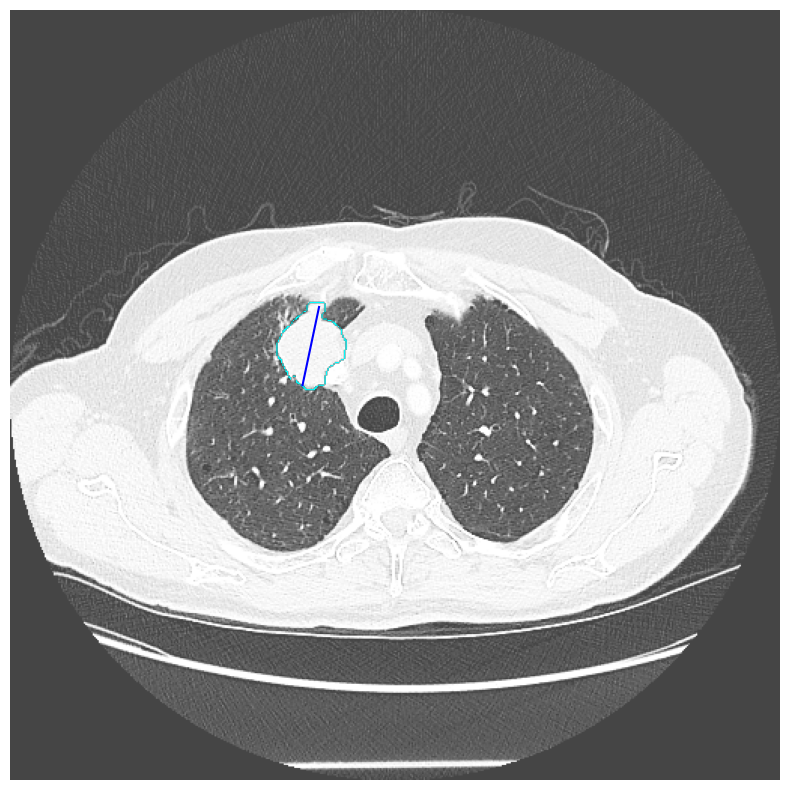

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(10,10))


displayCTSegOverlay(scan, outline, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=1, cmapSeg='cool_r', ax=ax)
ax.plot([recist_pts[0],recist_pts[2]], [recist_pts[1],recist_pts[3]], c='b')
# ax_index[2].scatter(, recist_pts[3], c='b', marker='+', s=6)